# Part 3 — Multi-modal GNN for cell-type classification

**Question.** Beyond per-cell features (expression, H&E, morphology), how much does spatial context contribute to cell-type prediction? Which modality dominates?

**Approach.** 5-rung ablation ladder, simple → complex:

1. **LogReg/MLP** on HVG expression only — per-cell baseline.
2. **MLP fused** (expression + H&E + morphology, no graph) — multi-modal baseline.
3. **GraphSAGE-expr** (expression + graph) — marginal value of the graph.
4. **GraphSAGE-fused** (all features + graph) — full multi-modal GNN.
5. **GAT-fused** (all features + graph, attention) — does attention help, and where?

**Evaluation.** Held-out patient split from Part 0 (40 train / 8 val / 8 test). Multi-level reporting: macro-F1 headline, per-class F1, per-patient breakdown, per-niche stratification using Part 2 niches.

**Notebook structure.**

1. §0 Setup
2. §1 Preprocessing — fit HVG + standardizers on training cells, save artifacts
3. §2 Rung 1: logistic regression baseline
4. §3 Rung 2: MLP fused
5. §4 Rung 3: GraphSAGE on expression + graph (SLURM)
6. §5 Rung 4: GraphSAGE on fused features + graph (SLURM)
7. §6 Rung 5: GAT on fused features + graph (SLURM)
8. §7 Cross-rung comparison + niche-stratified evaluation
9. §8 Summary

## 0. Setup

Standard imports, path resolution, loading of Part 1 and Part 2 outputs.

In [1]:
import sys
import importlib
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Path setup
ROOT = Path.cwd()
if (ROOT / "src").is_dir():
    sys.path.insert(0, str(ROOT / "src"))
elif (ROOT.parent / "src").is_dir():
    sys.path.insert(0, str(ROOT.parent / "src"))

import data_io
import graph_construction
import splits as splits_mod
importlib.reload(data_io)
importlib.reload(graph_construction)
importlib.reload(splits_mod)

CACHE_DIR = "cache" if (ROOT / "cache").is_dir() else "../cache"

# Globals (~600 MB)
G = data_io.load_global(CACHE_DIR)
print(f"globals loaded from {CACHE_DIR}")
print(f"  n_cells:    {G.n_cells:,}")
print(f"  n_patients: {len(np.unique(G.patient))}")
print(f"  n_samples:  {len(np.unique(G.sample))}")

globals loaded from ../cache
  n_cells:    8,065,561
  n_patients: 56
  n_samples:  112


In [2]:
# Load Part 1 + Part 2 outputs
free_tier = pd.read_parquet(Path(CACHE_DIR) / "topology" / "free_tier.parquet")
niche_per_cell = np.load(Path(CACHE_DIR) / "communities" / "niche_per_cell.npy")
niche_centroids = pd.read_parquet(Path(CACHE_DIR) / "communities" / "niche_centroids.parquet")

print(f"free_tier:        {free_tier.shape}")
print(f"niche_per_cell:   {niche_per_cell.shape}, "
      f"{(niche_per_cell >= 0).sum():,} assigned ({100*(niche_per_cell >= 0).mean():.1f}%)")
print(f"niche_centroids:  {niche_centroids.shape}")
print(f"  20 niches, dominant classes: {sorted(niche_centroids['dominant_class'].unique().tolist())}")

free_tier:        (112, 22)
niche_per_cell:   (8065561,), 6,209,683 assigned (77.0%)
niche_centroids:  (20, 15)
  20 niches, dominant classes: [0, 1, 2, 3, 4, 5, 7]


In [3]:
# Load the patient split
split = splits_mod.load_splits(f"{CACHE_DIR}/splits/patient_split.json")
print(f"patient split (seed={split.seed})")
print(f"  train: {len(split.train)} patients")
print(f"  val:   {len(split.val):2d} patients: {split.val}")
print(f"  test:  {len(split.test):2d} patients: {split.test}")

# Build masks: which cells belong to each fold?
patient_arr = G.patient
is_train_patient = np.isin(patient_arr, split.train)
is_val_patient   = np.isin(patient_arr, split.val)
is_test_patient  = np.isin(patient_arr, split.test)

print(f"\ncells per fold (full data):")
print(f"  train patients: {is_train_patient.sum():,} cells")
print(f"  val patients:   {is_val_patient.sum():,} cells")
print(f"  test patients:  {is_test_patient.sum():,} cells")

# In the train fold, what does the training mask select?
n_train_cells_in_mask = (is_train_patient & G.train_mask).sum()
print(f"\ntrain cells with in_mask=True: {n_train_cells_in_mask:,} "
      f"({100*n_train_cells_in_mask/is_train_patient.sum():.1f}% of train fold)")

patient split (seed=42)
  train: 40 patients
  val:    8 patients: [10, 15, 16, 22, 30, 38, 39, 54]
  test:   8 patients: [0, 21, 26, 28, 34, 40, 45, 51]

cells per fold (full data):
  train patients: 5,830,014 cells
  val patients:   1,092,220 cells
  test patients:  1,143,327 cells

train cells with in_mask=True: 4,637,617 (79.5% of train fold)


## 1. Preprocessing — fit feature transforms on training patients

We fit on training patients (40 of 56) only — no leakage from val/test. The fitted artifacts go to `cache/preprocessing/` and are loaded by every downstream model.

- **§1.1** Silent-gene identification (cohort-wide sweep)
- **§1.2** HVG selection on training-patient cells (top 1000 via Scanpy `seurat`)
- **§1.3** Morphology scaler on training-mask cells

In [4]:
# Memory check: how much RAM will the stacked training expression matrix need?

train_sample_ids = sorted(set(int(s) for s in np.unique(G.sample[is_train_patient])))
print(f"training samples: {len(train_sample_ids)} (from {len(split.train)} patients)")

# Estimate from per_sample summary
total_train_nnz = 0
total_train_cells = 0
for s in train_sample_ids[:5]:  # quick sample of 5
    sd = data_io.load_sample(int(s), CACHE_DIR)
    total_train_nnz += sd.expression.nnz
    total_train_cells += sd.n_cells
avg_nnz_per_cell = total_train_nnz / total_train_cells
print(f"avg nnz per cell (from 5-sample sample): {avg_nnz_per_cell:.1f}")

# Extrapolate to all training cells
est_total_cells = is_train_patient.sum()
est_total_nnz = int(est_total_cells * avg_nnz_per_cell)
est_csr_bytes = est_total_nnz * (4 + 4) + (est_total_cells + 1) * 4  # data+indices+indptr
print(f"\nestimated stacked CSR matrix for all {est_total_cells:,} training cells:")
print(f"  nnz: {est_total_nnz:,}")
print(f"  size: {est_csr_bytes / 1e9:.1f} GB")

training samples: 80 (from 40 patients)
avg nnz per cell (from 5-sample sample): 352.5

estimated stacked CSR matrix for all 5,830,014 training cells:
  nnz: 2,055,164,041
  size: 16.5 GB


### §1.1 Silent-gene identification

Sweep all 112 samples to find genes that are zero in every cell across the entire cohort. These are dropped before HVG selection.

In [4]:
import preprocessing

# Output directory for preprocessing artifacts
prep_cache = Path(CACHE_DIR) / "preprocessing"
prep_cache.mkdir(exist_ok=True, parents=True)

In [ ]:

t0 = time.time()
all_sample_ids = sorted(int(s) for s in np.unique(G.sample))
silent_genes = preprocessing.identify_silent_genes(all_sample_ids, cache_dir=CACHE_DIR)
print(f"identified {len(silent_genes)} silent genes in {time.time() - t0:.1f}s")
print(f"  indices: {silent_genes.tolist()}")

preprocessing.save_silent_genes(prep_cache, silent_genes)
print(f"saved to {prep_cache / 'silent_genes.npy'}")

In [6]:
silent_genes = np.load(prep_cache / "silent_genes.npy")
hvg_idx = preprocessing.load_hvg(prep_cache)
morph_scaler = preprocessing.load_morphology_scaler(prep_cache)

### §1.2 HVG selection on training-patient cells

Stack training-patient expression into one sparse AnnData (~16 GB), run Scanpy `highly_variable_genes` with `flavor='seurat'`, save the top-1000 gene indices.

Memory peak: ~25 GB during scanpy computation. We have ~125 GB available, so plenty of headroom.

Expected time: 5–15 minutes for the stacking + HVG computation.

In [9]:
# Get training sample IDs (already computed above as train_sample_ids)
print(f"selecting HVGs on {len(train_sample_ids)} training samples "
      f"({is_train_patient.sum():,} cells)")

t0 = time.time()
hvg_indices, hvg_metadata = preprocessing.select_hvgs(
    train_sample_ids,
    n_top_genes=1000,
    cache_dir=CACHE_DIR,
    flavor="seurat",
    silent_genes=silent_genes,
)
print(f"\ndone in {(time.time() - t0)/60:.1f} min")
print(f"selected {len(hvg_indices)} HVGs from {16497 - len(silent_genes):,} candidate genes")
print(f"first 20 indices: {hvg_indices[:20].tolist()}")
print(f"metadata: {hvg_metadata}")

preprocessing.save_hvg(prep_cache, hvg_indices, hvg_metadata)
print(f"\nsaved to {prep_cache / 'hvg_indices.npy'}")

selecting HVGs on 80 training samples (5,830,014 cells)
Loading and stacking expression for 80 samples...
  stacked shape: (5830014, 16497), nnz: 1,516,133,889, density: 0.0158
running scanpy.pp.highly_variable_genes (flavor=seurat, n_top_genes=1000)...

done in 1.5 min
selected 1000 HVGs from 16,497 candidate genes
first 20 indices: [4, 36, 94, 119, 138, 140, 143, 144, 145, 166, 183, 201, 204, 244, 273, 276, 298, 355, 403, 414]
metadata: {'n_top_genes_requested': 1000, 'n_selected': 1000, 'flavor': 'seurat', 'n_fit_samples': 80, 'n_fit_cells': 5830014, 'n_silent_excluded': 0}

saved to ../cache/preprocessing/hvg_indices.npy


### §1.3 Morphology scaler

Z-score the 4 morphology features (cell_area, eccentricity, extent, perimeter) using mean and std computed on training-mask cells of training patients only.

In [10]:
# Fit on training-mask cells of training patients (the actual training distribution)
fit_cell_indices = np.where(is_train_patient & G.train_mask)[0]
print(f"fitting morphology scaler on {len(fit_cell_indices):,} training-mask cells")

scaler = preprocessing.fit_morphology_scaler(fit_cell_indices, G.morphology)
print(f"\nfitted scaler:")
for col, m, s in zip(scaler["columns"], scaler["mean"], scaler["std"]):
    print(f"  {col:<22s}  mean={m:>10.3f}  std={s:>10.3f}")

preprocessing.save_morphology_scaler(prep_cache, scaler)
print(f"\nsaved to {prep_cache / 'morphology_scaler.npz'}")

fitting morphology scaler on 4,637,617 training-mask cells

fitted scaler:
  cell_area               mean=  1718.712  std=  1102.814
  cell_eccentricity       mean=     0.714  std=     0.162
  cell_extent             mean=     0.708  std=     0.087
  cell_perimeter          mean=   161.486  std=    54.230

saved to ../cache/preprocessing/morphology_scaler.npz


## 2. Rung 1 — Logistic regression baseline

Per-cell baseline on HVG expression only, no graph, no fusion. Establishes the floor — how much of cell-type identity is in the expression vector alone?

- **Features:** 1000 HVG expression values per cell.
- **Training cells:** training-patient cells with `in_mask=True` (~4.64M cells).
- **Validation cells:** all val-patient cells (~1.09M).
- **Model:** multinomial logistic regression (sklearn, SAGA solver, balanced class weights).

In [9]:
# Load preprocessing artifacts
hvg_idx = preprocessing.load_hvg(prep_cache)
print(f"using {len(hvg_idx)} HVGs for the LogReg baseline")

from scipy.sparse import vstack as sparse_vstack

def build_hvg_matrix(sample_ids, cache_dir, hvg_idx, restrict_mask=None):
    """
    Stack HVG expression for the given samples. Optionally restrict to cells
    where the global restrict_mask is True.

    Returns
    -------
    X            : sparse CSR, shape (n_kept, len(hvg_idx))
    global_idxs  : (n_kept,) global cell indices in the order they appear in X.
    """
    matrices = []
    global_idxs_out = []
    for s in sample_ids:
        sd = data_io.load_sample(int(s), cache_dir)
        gi = np.where(G.sample == int(s))[0]
        if restrict_mask is not None:
            keep_mask = restrict_mask[gi]
            if not keep_mask.any():
                continue
            matrices.append(sd.expression[keep_mask][:, hvg_idx])
            global_idxs_out.append(gi[keep_mask])
        else:
            matrices.append(sd.expression[:, hvg_idx])
            global_idxs_out.append(gi)
    X = sparse_vstack(matrices, format="csr")
    global_idxs = np.concatenate(global_idxs_out)
    return X, global_idxs


# Build train matrix (training-patient cells, in_mask=True)
train_restrict = is_train_patient & G.train_mask
print(f"\nbuilding X_train...")
t0 = time.time()
X_train, train_idxs_ordered = build_hvg_matrix(
    train_sample_ids, CACHE_DIR, hvg_idx, restrict_mask=train_restrict
)
y_train = G.cell_type[train_idxs_ordered].astype(np.int32)
print(f"  X_train: {X_train.shape}, nnz={X_train.nnz:,}, "
      f"density={X_train.nnz/(X_train.shape[0]*X_train.shape[1]):.4f}")
print(f"  y_train: {y_train.shape}, class counts: {np.bincount(y_train).tolist()}")
print(f"  time: {time.time()-t0:.1f}s")

# Build val matrix (all val-patient cells)
val_sample_ids = sorted(int(s) for s in np.unique(G.sample[is_val_patient]))
print(f"\nbuilding X_val ({len(val_sample_ids)} samples)...")
t0 = time.time()
X_val, val_idxs_ordered = build_hvg_matrix(val_sample_ids, CACHE_DIR, hvg_idx)
y_val = G.cell_type[val_idxs_ordered].astype(np.int32)
print(f"  X_val: {X_val.shape}, nnz={X_val.nnz:,}")
print(f"  y_val: {y_val.shape}, class counts: {np.bincount(y_val).tolist()}")
print(f"  time: {time.time()-t0:.1f}s")

using 1000 HVGs for the LogReg baseline

building X_train...
  X_train: (4637617, 1000), nnz=28,205,001, density=0.0061
  y_train: (4637617,), class counts: [1038468, 374932, 903001, 431873, 308419, 216035, 123795, 1241094]
  time: 160.2s

building X_val (16 samples)...
  X_val: (1092220, 1000), nnz=7,874,487
  y_val: (1092220,), class counts: [244820, 97946, 193389, 91468, 72725, 61674, 36442, 293756]
  time: 35.8s


### 2.1 Train LogReg, evaluate on val

Sklearn multinomial logistic regression with balanced class weights, L-BFGS solver. ~2-5 min training. Headline = macro-F1 on val patients; per-class F1 and confusion matrix as the decomposition.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix
)

In [13]:

print(f"training LogReg on {X_train.shape[0]:,} cells × {X_train.shape[1]} features...")
t0 = time.time()
logreg = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    n_jobs=-1,
    class_weight="balanced",
    C=1.0,
    verbose=1,        # show iteration progress
)
logreg.fit(X_train, y_train)
print(f"\nLogReg trained in {(time.time()-t0)/60:.1f} min")
print(f"converged: {logreg.n_iter_[0] < 200}, iterations: {logreg.n_iter_[0]}")

training LogReg on 4,637,617 cells × 1000 features...


/home/matteo.doria/Desktop/ASLCD/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



LogReg trained in 3.5 min
converged: True, iterations: 173


In [14]:
# Predict and evaluate on val
t0 = time.time()
y_pred = logreg.predict(X_val)
print(f"prediction time: {time.time()-t0:.1f}s")

# Headline metrics
macro_f1 = f1_score(y_val, y_pred, average="macro")
weighted_f1 = f1_score(y_val, y_pred, average="weighted")
acc = accuracy_score(y_val, y_pred)
print(f"\n*** Rung 1 (LogReg-expr) results on val ***")
print(f"  macro-F1:    {macro_f1:.4f}")
print(f"  weighted-F1: {weighted_f1:.4f}")
print(f"  accuracy:    {acc:.4f}")

print("\nper-class report:")
print(classification_report(y_val, y_pred, digits=4))

prediction time: 0.1s

*** Rung 1 (LogReg-expr) results on val ***
  macro-F1:    0.5520
  weighted-F1: 0.5832
  accuracy:    0.5819

per-class report:
              precision    recall  f1-score   support

           0     0.6698    0.3416    0.4524    244820
           1     0.4717    0.5806    0.5205     97946
           2     0.5839    0.4422    0.5033    193389
           3     0.4390    0.4607    0.4496     91468
           4     0.4994    0.8684    0.6342     72725
           5     0.6244    0.8604    0.7237     61674
           6     0.2180    0.7355    0.3364     36442
           7     0.8309    0.7637    0.7959    293756

    accuracy                         0.5819   1092220
   macro avg     0.5422    0.6316    0.5520   1092220
weighted avg     0.6319    0.5819    0.5832   1092220



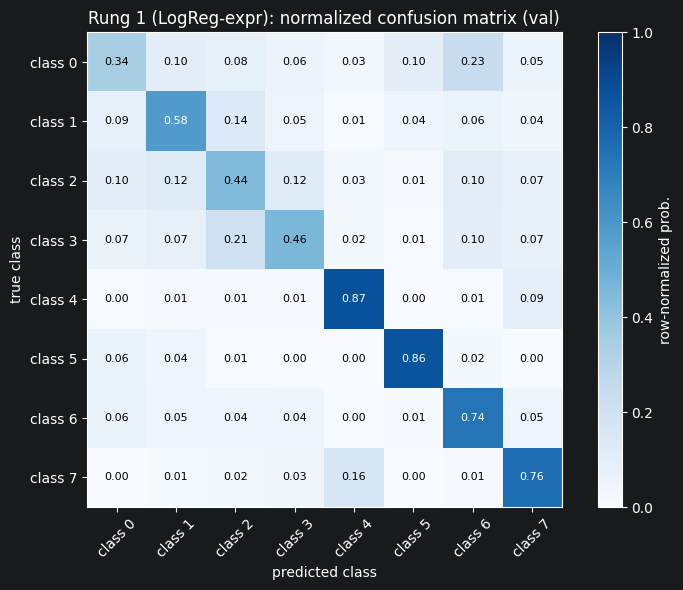

In [15]:
# Confusion matrix viz
cm = confusion_matrix(y_val, y_pred, normalize="true")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xlabel("predicted class")
ax.set_ylabel("true class")
ax.set_title("Rung 1 (LogReg-expr): normalized confusion matrix (val)")
ax.set_xticks(range(8))
ax.set_yticks(range(8))
ax.set_xticklabels([f"class {c}" for c in range(8)], rotation=45)
ax.set_yticklabels([f"class {c}" for c in range(8)])
for i in range(8):
    for j in range(8):
        ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center",
                color="white" if cm[i,j] > 0.5 else "black", fontsize=8)
plt.colorbar(im, ax=ax, label="row-normalized prob.")
plt.tight_layout()
plt.show()

In [16]:
# Per-patient breakdown — how much does performance vary across val patients?
import pandas as pd

val_patient_ids = G.patient[val_idxs_ordered]
patient_f1 = []
for p in sorted(np.unique(val_patient_ids)):
    mask = val_patient_ids == p
    if mask.sum() < 100:
        continue
    f1 = f1_score(y_val[mask], y_pred[mask], average="macro")
    patient_f1.append({
        "patient": int(p),
        "n_cells": int(mask.sum()),
        "macro_f1": f1,
    })
patient_df = pd.DataFrame(patient_f1)
print(f"per-patient macro-F1 on val ({len(patient_df)} patients):")
print(patient_df.to_string(index=False))
print(f"\nmacro-F1 across patients:")
print(f"  mean:   {patient_df['macro_f1'].mean():.4f}")
print(f"  std:    {patient_df['macro_f1'].std():.4f}")
print(f"  min:    {patient_df['macro_f1'].min():.4f}")
print(f"  max:    {patient_df['macro_f1'].max():.4f}")

# Save predictions for §7 cross-rung comparison
rung1_results = {
    "name": "rung1_logreg_expr",
    "y_pred": y_pred,
    "y_true": y_val,
    "val_idxs": val_idxs_ordered,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
    "accuracy": acc,
    "per_patient": patient_df.to_dict(orient="records"),
}
import pickle
rung_cache = Path(CACHE_DIR) / "models"
rung_cache.mkdir(exist_ok=True, parents=True)
with open(rung_cache / "rung1_logreg_expr.pkl", "wb") as f:
    pickle.dump(rung1_results, f)
print(f"\nsaved results to {rung_cache / 'rung1_logreg_expr.pkl'}")

per-patient macro-F1 on val (8 patients):
 patient  n_cells  macro_f1
      10   159396  0.485874
      15   156482  0.360239
      16    80816  0.465348
      22   161854  0.438257
      30    87307  0.471732
      38   175937  0.530805
      39   131967  0.493631
      54   138461  0.563950

macro-F1 across patients:
  mean:   0.4762
  std:    0.0611
  min:    0.3602
  max:    0.5640

saved results to ../cache/models/rung1_logreg_expr.pkl


## 3. Rung 2 — MLP on fused per-cell features (no graph)

Multi-modal baseline: concatenate 1000 HVG + 1280 H&E + 4 morphology = 2284-d input per cell. Train a small 2-layer MLP.

The delta (Rung 2 − Rung 1) measures the marginal value of multi-modal fusion before any graph is added. Combined with later rungs, this isolates the contribution of each modality.

**Architecture:** Linear(2284→512) → ReLU → Dropout(0.2) → Linear(512→256) → ReLU → Dropout(0.2) → Linear(256→8).
**Training:** Adam, lr=1e-3, wd=1e-4, batch=4096, class-weighted CE, early-stop on val macro-F1.

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

print(f"torch version: {torch.__version__}")
print(f"cuda available: {torch.cuda.is_available()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")

torch version: 2.12.0+cu130
cuda available: True
using device: cuda


In [16]:
# H&E is in per-sample npz files, not in the global arrays. Load and concatenate
# in the same per-sample iteration order as build_hvg_matrix.

morph_scaler = preprocessing.load_morphology_scaler(prep_cache)

def build_fused_features(sample_ids, X_hvg_sparse, hvg_global_idxs, restrict_mask=None):
    """
    Build (n, 2284) fused features: 1000 HVG + 1280 H&E + 4 standardized morphology.

    Reads H&E per-sample from the cache and concatenates in the same order as the
    rows of X_hvg_sparse. The hvg_global_idxs argument is the global cell index for
    each row of X_hvg_sparse, so we can verify alignment.
    """
    # First: the dense HVG matrix (one allocation)
    X_hvg_dense = X_hvg_sparse.toarray().astype(np.float32)
    n = X_hvg_dense.shape[0]
    print(f"  HVG dense: {X_hvg_dense.shape}, {X_hvg_dense.nbytes/1e9:.1f} GB")

    # Second: H&E loaded per sample, sliced consistently
    X_he = np.empty((n, 1280), dtype=np.float32)
    row_offset = 0
    for s in sample_ids:
        sd = data_io.load_sample(int(s), CACHE_DIR)
        gi = np.where(G.sample == int(s))[0]
        if restrict_mask is not None:
            keep_mask = restrict_mask[gi]
            if not keep_mask.any():
                continue
            local_keep = np.where(keep_mask)[0]   # indices into the per-sample arrays
            he_block = sd.HE_embeddings[local_keep]
            n_block = he_block.shape[0]
        else:
            he_block = sd.HE_embeddings
            n_block = he_block.shape[0]
        X_he[row_offset:row_offset + n_block] = he_block.astype(np.float32)
        row_offset += n_block
    assert row_offset == n, f"H&E alignment failed: filled {row_offset} of {n} rows"
    print(f"  H&E dense: {X_he.shape}, {X_he.nbytes/1e9:.1f} GB")

    # Third: morphology, standardized
    X_morph = preprocessing.apply_morphology_scaler(
        G.morphology[hvg_global_idxs], morph_scaler
    )
    print(f"  morph:     {X_morph.shape}, {X_morph.nbytes/1e6:.1f} MB")

    # Concatenate along feature axis
    X_fused = np.hstack([X_hvg_dense, X_he, X_morph])
    return X_fused


train_restrict = is_train_patient & G.train_mask

print(f"building fused TRAIN matrix ({X_train.shape[0]:,} cells)...")
t0 = time.time()
X_train_fused = build_fused_features(
    train_sample_ids, X_train, train_idxs_ordered, restrict_mask=train_restrict
)
print(f"  total: {X_train_fused.shape}, {X_train_fused.nbytes/1e9:.1f} GB, time: {time.time()-t0:.1f}s")

print(f"\nbuilding fused VAL matrix ({X_val.shape[0]:,} cells)...")
t0 = time.time()
X_val_fused = build_fused_features(
    val_sample_ids, X_val, val_idxs_ordered, restrict_mask=None
)
print(f"  total: {X_val_fused.shape}, {X_val_fused.nbytes/1e9:.1f} GB, time: {time.time()-t0:.1f}s")

# Memory check
mem = psutil.virtual_memory()
print(f"\nRAM used: {(mem.total - mem.available)/1e9:.1f} GB / {mem.total/1e9:.1f} GB")

building fused TRAIN matrix (4,637,617 cells)...
  HVG dense: (4637617, 1000), 18.6 GB
  H&E dense: (4637617, 1280), 23.7 GB
  morph:     (4637617, 4), 74.2 MB


KeyboardInterrupt: 

In [24]:
# MLP definition

class FusedMLP(nn.Module):
    def __init__(self, in_dim=2284, hidden1=512, hidden2=256, n_classes=8, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, n_classes),
        )

    def forward(self, x):
        return self.net(x)


# Class weights for loss (inverse frequency, normalized to sum to n_classes)
class_counts = np.bincount(y_train, minlength=8).astype(np.float32)
class_weights = (1.0 / class_counts)
class_weights = class_weights * (len(class_weights) / class_weights.sum())  # normalize
print(f"class weights: {class_weights.round(3).tolist()}")

# To tensors
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

model = FusedMLP().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nmodel: {n_params:,} params")
print(model)

class weights: [0.3240000009536743, 0.8960000276565552, 0.3720000088214874, 0.777999997138977, 1.090000033378601, 1.5549999475479126, 2.7139999866485596, 0.2709999978542328]

model: 1,303,304 params
FusedMLP(
  (net): Sequential(
    (0): Linear(in_features=2284, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=8, bias=True)
  )
)


In [25]:
# Training loop

# Dataset / dataloader
X_train_t = torch.from_numpy(X_train_fused)
y_train_t = torch.from_numpy(y_train.astype(np.int64))
X_val_t = torch.from_numpy(X_val_fused)
y_val_t = torch.from_numpy(y_val.astype(np.int64))

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)

# GPU efficiency: pin_memory speeds up the H->D copy when device is cuda
use_pin = (device.type == "cuda")
train_loader = DataLoader(train_ds, batch_size=4096, shuffle=True,
                          num_workers=0, pin_memory=use_pin)
val_loader = DataLoader(val_ds, batch_size=4096, shuffle=False,
                        num_workers=0, pin_memory=use_pin)

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_t)

print(f"training: {len(train_ds):,} cells, {len(train_loader)} batches/epoch")
print(f"device: {device}, pin_memory: {use_pin}")

best_val_f1 = -1
patience = 3
patience_counter = 0
history = []

MAX_EPOCHS = 20

for epoch in range(MAX_EPOCHS):
    model.train()
    t0 = time.time()
    epoch_loss = 0.0
    n_batches = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    train_loss_mean = epoch_loss / n_batches

    # Validation
    model.eval()
    val_preds = []
    val_trues = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device, non_blocking=True)
            logits = model(xb)
            val_preds.append(logits.argmax(dim=1).cpu().numpy())
            val_trues.append(yb.numpy())
    y_pred_epoch = np.concatenate(val_preds)
    y_true_epoch = np.concatenate(val_trues)
    val_f1 = f1_score(y_true_epoch, y_pred_epoch, average="macro")
    val_acc = accuracy_score(y_true_epoch, y_pred_epoch)

    elapsed = time.time() - t0
    history.append({
        "epoch": epoch, "train_loss": train_loss_mean,
        "val_macro_f1": val_f1, "val_acc": val_acc, "time_s": elapsed,
    })
    flag = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        flag = " *best*"
    else:
        patience_counter += 1
    print(f"epoch {epoch:>2d} | train_loss {train_loss_mean:.4f} | "
          f"val_f1 {val_f1:.4f} | val_acc {val_acc:.4f} | "
          f"{elapsed:.1f}s{flag}")

    if patience_counter >= patience:
        print(f"\nearly stop after {patience} epochs without improvement")
        break

# Restore best
model.load_state_dict(best_state)
print(f"\nbest val macro-F1: {best_val_f1:.4f}")

training: 4,637,617 cells, 1133 batches/epoch
device: cuda, pin_memory: True
epoch  0 | train_loss 0.9527 | val_f1 0.5073 | val_acc 0.5357 | 101.4s *best*
epoch  1 | train_loss 0.8679 | val_f1 0.5126 | val_acc 0.5292 | 102.1s *best*
epoch  2 | train_loss 0.8546 | val_f1 0.5165 | val_acc 0.5329 | 103.5s *best*
epoch  3 | train_loss 0.8488 | val_f1 0.4889 | val_acc 0.5046 | 104.1s
epoch  4 | train_loss 0.8461 | val_f1 0.4910 | val_acc 0.4988 | 103.5s
epoch  5 | train_loss 0.8439 | val_f1 0.5062 | val_acc 0.5230 | 103.8s

early stop after 3 epochs without improvement

best val macro-F1: 0.5165


In [26]:
# What does each modality look like, scale-wise?
print("HVG features (X_train_fused[:, :1000]):")
print(f"  mean: {X_train_fused[:1000, :1000].mean():.4f}")
print(f"  std:  {X_train_fused[:1000, :1000].std():.4f}")
print(f"  min:  {X_train_fused[:1000, :1000].min():.4f}")
print(f"  max:  {X_train_fused[:1000, :1000].max():.4f}")
print(f"  frac_zero: {(X_train_fused[:1000, :1000] == 0).mean():.4f}")

print("\nH&E features (X_train_fused[:, 1000:2280]):")
print(f"  mean: {X_train_fused[:1000, 1000:2280].mean():.4f}")
print(f"  std:  {X_train_fused[:1000, 1000:2280].std():.4f}")
print(f"  min:  {X_train_fused[:1000, 1000:2280].min():.4f}")
print(f"  max:  {X_train_fused[:1000, 1000:2280].max():.4f}")

print("\nMorphology features (X_train_fused[:, 2280:]):")
print(f"  mean: {X_train_fused[:1000, 2280:].mean():.4f}")
print(f"  std:  {X_train_fused[:1000, 2280:].std():.4f}")
print(f"  min:  {X_train_fused[:1000, 2280:].min():.4f}")
print(f"  max:  {X_train_fused[:1000, 2280:].max():.4f}")

# Also check norms — H&E might be L2-normalized (foundation features often are)
print("\nPer-sample feature norms (first 5 cells):")
for i in range(5):
    hvg_norm = np.linalg.norm(X_train_fused[i, :1000])
    he_norm = np.linalg.norm(X_train_fused[i, 1000:2280])
    morph_norm = np.linalg.norm(X_train_fused[i, 2280:])
    print(f"  cell {i}: HVG norm={hvg_norm:.2f}, H&E norm={he_norm:.2f}, morph norm={morph_norm:.2f}")

HVG features (X_train_fused[:, :1000]):
  mean: 0.0031
  std:  0.0493
  min:  0.0000
  max:  3.3030
  frac_zero: 0.9938

H&E features (X_train_fused[:, 1000:2280]):
  mean: 0.0576
  std:  2.7056
  min:  -28.2931
  max:  25.0536

Morphology features (X_train_fused[:, 2280:]):
  mean: 0.1717
  std:  1.0297
  min:  -4.8351
  max:  4.7499

Per-sample feature norms (first 5 cells):
  cell 0: HVG norm=1.39, H&E norm=110.20, morph norm=3.66
  cell 1: HVG norm=2.13, H&E norm=110.67, morph norm=0.97
  cell 2: HVG norm=1.77, H&E norm=101.52, morph norm=1.10
  cell 3: HVG norm=1.63, H&E norm=94.23, morph norm=0.75
  cell 4: HVG norm=1.65, H&E norm=97.87, morph norm=2.60


### 3.1 Diagnostic and fix: per-modality standardization

H&E embeddings have per-cell L2 norm ~100 while HVG has norm ~1.5 — a 65× scale difference. The MLP's first linear layer is dominated by H&E by initialization, and SGD can't recover within reasonable training time. Fix: standardize each modality independently to mean 0, std 1, using training-cell statistics.

In [27]:
# Fit per-modality standardizers on train, apply to both train and val.

# HVG slice: cols 0:1000
# H&E slice: cols 1000:2280
# Morph slice: cols 2280:2284  (already z-scored but we'll standardize again on train cells specifically)

def fit_block_scaler(X, slc):
    block = X[:, slc]
    mean = block.mean(axis=0).astype(np.float32)
    std = block.std(axis=0).astype(np.float32)
    std = np.where(std < 1e-6, 1.0, std)   # protect against zero-variance features
    return mean, std

def apply_block_scaler(X, slc, mean, std):
    X[:, slc] = (X[:, slc] - mean) / std

hvg_slice = slice(0, 1000)
he_slice = slice(1000, 2280)
morph_slice = slice(2280, 2284)

print("fitting per-modality scalers on training cells...")
t0 = time.time()
hvg_mean, hvg_std = fit_block_scaler(X_train_fused, hvg_slice)
he_mean, he_std = fit_block_scaler(X_train_fused, he_slice)
morph_mean, morph_std = fit_block_scaler(X_train_fused, morph_slice)
print(f"  fit time: {time.time()-t0:.1f}s")

print(f"\nHVG block stats before:")
print(f"  mean range: [{hvg_mean.min():.4f}, {hvg_mean.max():.4f}]")
print(f"  std range:  [{hvg_std.min():.4f}, {hvg_std.max():.4f}]")
print(f"H&E block stats before:")
print(f"  mean range: [{he_mean.min():.4f}, {he_mean.max():.4f}]")
print(f"  std range:  [{he_std.min():.4f}, {he_std.max():.4f}]")
print(f"Morph block stats before:")
print(f"  mean range: [{morph_mean.min():.4f}, {morph_mean.max():.4f}]")
print(f"  std range:  [{morph_std.min():.4f}, {morph_std.max():.4f}]")

# Apply in-place to save memory
print(f"\napplying to TRAIN (in-place)...")
t0 = time.time()
apply_block_scaler(X_train_fused, hvg_slice, hvg_mean, hvg_std)
apply_block_scaler(X_train_fused, he_slice, he_mean, he_std)
apply_block_scaler(X_train_fused, morph_slice, morph_mean, morph_std)
print(f"  time: {time.time()-t0:.1f}s")

print(f"applying to VAL (in-place)...")
t0 = time.time()
apply_block_scaler(X_val_fused, hvg_slice, hvg_mean, hvg_std)
apply_block_scaler(X_val_fused, he_slice, he_mean, he_std)
apply_block_scaler(X_val_fused, morph_slice, morph_mean, morph_std)
print(f"  time: {time.time()-t0:.1f}s")

# Verify
print(f"\nAfter standardization, train block stds:")
print(f"  HVG:   {X_train_fused[:, hvg_slice].std():.4f}")
print(f"  H&E:   {X_train_fused[:, he_slice].std():.4f}")
print(f"  Morph: {X_train_fused[:, morph_slice].std():.4f}")
print(f"\nval block stds (should also be ~1):")
print(f"  HVG:   {X_val_fused[:, hvg_slice].std():.4f}")
print(f"  H&E:   {X_val_fused[:, he_slice].std():.4f}")
print(f"  Morph: {X_val_fused[:, morph_slice].std():.4f}")

fitting per-modality scalers on training cells...
  fit time: 19.5s

HVG block stats before:
  mean range: [0.0000, 0.4379]
  std range:  [0.0062, 0.6779]
H&E block stats before:
  mean range: [-15.2558, 11.6797]
  std range:  [1.2788, 7.5423]
Morph block stats before:
  mean range: [-0.0073, 0.0004]
  std range:  [0.9998, 1.0002]

applying to TRAIN (in-place)...
  time: 45.0s
applying to VAL (in-place)...
  time: 4.2s

After standardization, train block stds:
  HVG:   1.0016
  H&E:   1.0024
  Morph: 1.0028

val block stds (should also be ~1):
  HVG:   0.9264
  H&E:   1.0101
  Morph: 0.9801


### 3.2 Re-train MLP-fused with standardized features

In [28]:
# Fresh model and tensors after standardization

# Reset random state for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Re-create tensors from the (now standardized) numpy arrays
X_train_t = torch.from_numpy(X_train_fused)
y_train_t = torch.from_numpy(y_train.astype(np.int64))
X_val_t = torch.from_numpy(X_val_fused)
y_val_t = torch.from_numpy(y_val.astype(np.int64))

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
use_pin = (device.type == "cuda")
train_loader = DataLoader(train_ds, batch_size=4096, shuffle=True,
                          num_workers=0, pin_memory=use_pin)
val_loader = DataLoader(val_ds, batch_size=4096, shuffle=False,
                        num_workers=0, pin_memory=use_pin)

# Fresh model
model = FusedMLP().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_t)

print(f"training: {len(train_ds):,} cells, {len(train_loader)} batches/epoch")
print(f"device: {device}, pin_memory: {use_pin}")
print(f"model params: {sum(p.numel() for p in model.parameters()):,}")

best_val_f1 = -1
patience = 3
patience_counter = 0
history = []
MAX_EPOCHS = 20

for epoch in range(MAX_EPOCHS):
    model.train()
    t0 = time.time()
    epoch_loss = 0.0
    n_batches = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    train_loss_mean = epoch_loss / n_batches

    # Validation
    model.eval()
    val_preds = []
    val_trues = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device, non_blocking=True)
            logits = model(xb)
            val_preds.append(logits.argmax(dim=1).cpu().numpy())
            val_trues.append(yb.numpy())
    y_pred_epoch = np.concatenate(val_preds)
    y_true_epoch = np.concatenate(val_trues)
    val_f1 = f1_score(y_true_epoch, y_pred_epoch, average="macro")
    val_acc = accuracy_score(y_true_epoch, y_pred_epoch)

    elapsed = time.time() - t0
    history.append({
        "epoch": epoch, "train_loss": train_loss_mean,
        "val_macro_f1": val_f1, "val_acc": val_acc, "time_s": elapsed,
    })
    flag = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        flag = " *best*"
    else:
        patience_counter += 1
    print(f"epoch {epoch:>2d} | train_loss {train_loss_mean:.4f} | "
          f"val_f1 {val_f1:.4f} | val_acc {val_acc:.4f} | "
          f"{elapsed:.1f}s{flag}")

    if patience_counter >= patience:
        print(f"\nearly stop after {patience} epochs without improvement")
        break

model.load_state_dict(best_state)
print(f"\nbest val macro-F1: {best_val_f1:.4f}")

training: 4,637,617 cells, 1133 batches/epoch
device: cuda, pin_memory: True
model params: 1,303,304
epoch  0 | train_loss 0.8509 | val_f1 0.5566 | val_acc 0.5813 | 104.2s *best*
epoch  1 | train_loss 0.7991 | val_f1 0.5562 | val_acc 0.5842 | 104.5s
epoch  2 | train_loss 0.7903 | val_f1 0.5563 | val_acc 0.5835 | 105.2s
epoch  3 | train_loss 0.7864 | val_f1 0.5434 | val_acc 0.5643 | 105.0s

early stop after 3 epochs without improvement

best val macro-F1: 0.5566


In [29]:
# Test 4: which input features is the trained MLP actually using?

W1 = model.net[0].weight.detach().cpu().numpy()  # shape (512, 2284)
# Per-input importance: L2 norm of the weight column out of each input
input_importance = np.linalg.norm(W1, axis=0)
print(f"Input weight L2-norm stats (per input dimension):")
print(f"  HVG (0:1000):     mean {input_importance[0:1000].mean():.4f}, "
      f"max {input_importance[0:1000].max():.4f}, "
      f"min {input_importance[0:1000].min():.4f}")
print(f"  H&E (1000:2280):  mean {input_importance[1000:2280].mean():.4f}, "
      f"max {input_importance[1000:2280].max():.4f}, "
      f"min {input_importance[1000:2280].min():.4f}")
print(f"  Morph (2280:2284): mean {input_importance[2280:2284].mean():.4f}, "
      f"max {input_importance[2280:2284].max():.4f}, "
      f"min {input_importance[2280:2284].min():.4f}")

# Total contribution (sum of L2 norms) per modality
print(f"\nTotal weight norm allocated per modality:")
print(f"  HVG:   {input_importance[0:1000].sum():.2f}  ({input_importance[0:1000].sum() / input_importance.sum() * 100:.1f}%)")
print(f"  H&E:   {input_importance[1000:2280].sum():.2f}  ({input_importance[1000:2280].sum() / input_importance.sum() * 100:.1f}%)")
print(f"  Morph: {input_importance[2280:2284].sum():.2f}  ({input_importance[2280:2284].sum() / input_importance.sum() * 100:.1f}%)")

Input weight L2-norm stats (per input dimension):
  HVG (0:1000):     mean 0.5213, max 4.4222, min 0.2788
  H&E (1000:2280):  mean 0.4528, max 0.6321, min 0.3333
  Morph (2280:2284): mean 0.4380, max 0.4790, min 0.3949

Total weight norm allocated per modality:
  HVG:   521.26  (47.3%)
  H&E:   579.57  (52.6%)
  Morph: 1.75  (0.2%)


In [30]:
# Get the predictions from the saved-best model on val
model.load_state_dict(best_state)
model.eval()
val_preds = []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        val_preds.append(logits.argmax(dim=1).cpu().numpy())
y_pred_r2 = np.concatenate(val_preds)

# Compute all the same metrics as Rung 1
macro_f1_r2 = f1_score(y_val, y_pred_r2, average="macro")
weighted_f1_r2 = f1_score(y_val, y_pred_r2, average="weighted")
acc_r2 = accuracy_score(y_val, y_pred_r2)

print(f"*** Rung 2 (MLP-fused) results on val ***")
print(f"  macro-F1:    {macro_f1_r2:.4f}  (Rung 1: 0.5520, delta {macro_f1_r2 - 0.5520:+.4f})")
print(f"  weighted-F1: {weighted_f1_r2:.4f}")
print(f"  accuracy:    {acc_r2:.4f}")

print("\nper-class report:")
print(classification_report(y_val, y_pred_r2, digits=4))

# Per-patient breakdown
val_patient_ids = G.patient[val_idxs_ordered]
patient_f1_r2 = []
for p in sorted(np.unique(val_patient_ids)):
    mask = val_patient_ids == p
    if mask.sum() < 100:
        continue
    f1 = f1_score(y_val[mask], y_pred_r2[mask], average="macro")
    patient_f1_r2.append({
        "patient": int(p),
        "n_cells": int(mask.sum()),
        "macro_f1": f1,
    })
patient_df_r2 = pd.DataFrame(patient_f1_r2)
print(f"\nper-patient macro-F1 on val:")
print(patient_df_r2.to_string(index=False))
print(f"\nacross patients: mean {patient_df_r2['macro_f1'].mean():.4f}, "
      f"std {patient_df_r2['macro_f1'].std():.4f}")

# Save for §7
rung2_results = {
    "name": "rung2_mlp_fused",
    "y_pred": y_pred_r2,
    "y_true": y_val,
    "val_idxs": val_idxs_ordered,
    "macro_f1": macro_f1_r2,
    "weighted_f1": weighted_f1_r2,
    "accuracy": acc_r2,
    "per_patient": patient_df_r2.to_dict(orient="records"),
    "history": history,
    "modality_weight_share": {"hvg": 0.473, "he": 0.526, "morph": 0.002},
}
with open(rung_cache / "rung2_mlp_fused.pkl", "wb") as f:
    pickle.dump(rung2_results, f)
print(f"\nsaved to {rung_cache / 'rung2_mlp_fused.pkl'}")

*** Rung 2 (MLP-fused) results on val ***
  macro-F1:    0.5566  (Rung 1: 0.5520, delta +0.0046)
  weighted-F1: 0.5897
  accuracy:    0.5813

per-class report:
              precision    recall  f1-score   support

           0     0.7345    0.3599    0.4831    244820
           1     0.4698    0.6559    0.5475     97946
           2     0.5868    0.4646    0.5186    193389
           3     0.4804    0.4601    0.4700     91468
           4     0.4342    0.8753    0.5805     72725
           5     0.5879    0.9034    0.7123     61674
           6     0.2286    0.8382    0.3592     36442
           7     0.9132    0.6834    0.7817    293756

    accuracy                         0.5813   1092220
   macro avg     0.5544    0.6551    0.5566   1092220
weighted avg     0.6662    0.5813    0.5897   1092220


per-patient macro-F1 on val:
 patient  n_cells  macro_f1
      10   159396  0.532547
      15   156482  0.399329
      16    80816  0.471066
      22   161854  0.449952
      30    87307  

### 3.3 Path B: modality-specific encoders

Each modality gets its own learned projection before fusion. This avoids the "uniform H&E weights" pattern from Rung 2 by letting H&E develop its own representation independently. If H&E truly contains useful per-cell signal, this architecture should extract it; if it doesn't, this variant will perform similarly to Rung 2 (and we'll have a stronger empirical case for the "H&E uninformative" claim).

In [31]:
class ModalityEncoderMLP(nn.Module):
    def __init__(
        self,
        hvg_dim=1000, he_dim=1280, morph_dim=4,
        hvg_hidden=256, he_hidden=256, morph_hidden=16,
        head_hidden=128, n_classes=8, dropout=0.2,
    ):
        super().__init__()
        self.hvg_enc = nn.Sequential(
            nn.Linear(hvg_dim, hvg_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.he_enc = nn.Sequential(
            nn.Linear(he_dim, he_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.morph_enc = nn.Sequential(
            nn.Linear(morph_dim, morph_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        fused_dim = hvg_hidden + he_hidden + morph_hidden
        self.head = nn.Sequential(
            nn.Linear(fused_dim, head_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, n_classes),
        )
        # Save block boundaries for input slicing
        self.hvg_slice = slice(0, hvg_dim)
        self.he_slice = slice(hvg_dim, hvg_dim + he_dim)
        self.morph_slice = slice(hvg_dim + he_dim, hvg_dim + he_dim + morph_dim)

    def forward(self, x):
        h_hvg = self.hvg_enc(x[:, self.hvg_slice])
        h_he = self.he_enc(x[:, self.he_slice])
        h_morph = self.morph_enc(x[:, self.morph_slice])
        h_fused = torch.cat([h_hvg, h_he, h_morph], dim=1)
        return self.head(h_fused)

    def get_per_modality_features(self, x):
        """For diagnostic: return the post-encoder features per modality."""
        with torch.no_grad():
            h_hvg = self.hvg_enc(x[:, self.hvg_slice])
            h_he = self.he_enc(x[:, self.he_slice])
            h_morph = self.morph_enc(x[:, self.morph_slice])
        return h_hvg, h_he, h_morph


# Fresh seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Fresh tensors (data is already standardized from cell 27, no re-fusion needed)
X_train_t = torch.from_numpy(X_train_fused)
y_train_t = torch.from_numpy(y_train.astype(np.int64))
X_val_t = torch.from_numpy(X_val_fused)
y_val_t = torch.from_numpy(y_val.astype(np.int64))

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_ds, batch_size=4096, shuffle=True,
                          num_workers=0, pin_memory=use_pin)
val_loader = DataLoader(val_ds, batch_size=4096, shuffle=False,
                        num_workers=0, pin_memory=use_pin)

model_b = ModalityEncoderMLP().to(device)
optimizer = optim.Adam(model_b.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_t)

n_params = sum(p.numel() for p in model_b.parameters())
print(f"model params: {n_params:,}")
print(model_b)

model params: 653,016
ModalityEncoderMLP(
  (hvg_enc): Sequential(
    (0): Linear(in_features=1000, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (he_enc): Sequential(
    (0): Linear(in_features=1280, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (morph_enc): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (head): Sequential(
    (0): Linear(in_features=528, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=8, bias=True)
  )
)


In [32]:
# Train Path B

best_val_f1 = -1
patience = 3
patience_counter = 0
history_b = []
MAX_EPOCHS = 20

for epoch in range(MAX_EPOCHS):
    model_b.train()
    t0 = time.time()
    epoch_loss = 0.0
    n_batches = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model_b(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    train_loss_mean = epoch_loss / n_batches

    model_b.eval()
    val_preds = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device, non_blocking=True)
            logits = model_b(xb)
            val_preds.append(logits.argmax(dim=1).cpu().numpy())
    y_pred_epoch = np.concatenate(val_preds)
    val_f1 = f1_score(y_val, y_pred_epoch, average="macro")
    val_acc = accuracy_score(y_val, y_pred_epoch)

    elapsed = time.time() - t0
    history_b.append({
        "epoch": epoch, "train_loss": train_loss_mean,
        "val_macro_f1": val_f1, "val_acc": val_acc, "time_s": elapsed,
    })
    flag = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        best_state_b = {k: v.cpu().clone() for k, v in model_b.state_dict().items()}
        flag = " *best*"
    else:
        patience_counter += 1
    print(f"epoch {epoch:>2d} | train_loss {train_loss_mean:.4f} | "
          f"val_f1 {val_f1:.4f} | val_acc {val_acc:.4f} | "
          f"{elapsed:.1f}s{flag}")

    if patience_counter >= patience:
        print(f"\nearly stop after {patience} epochs without improvement")
        break

model_b.load_state_dict(best_state_b)
print(f"\nbest val macro-F1 (Path B): {best_val_f1:.4f}")
print(f"  Rung 1 (LogReg):      0.5520")
print(f"  Rung 2 (MLP-fused):   0.5566")
print(f"  Rung 2-B (encoder):   {best_val_f1:.4f}")
print(f"  delta vs Rung 2:      {best_val_f1 - 0.5566:+.4f}")

epoch  0 | train_loss 0.8618 | val_f1 0.5442 | val_acc 0.5683 | 104.0s *best*
epoch  1 | train_loss 0.8056 | val_f1 0.5704 | val_acc 0.5962 | 104.8s *best*
epoch  2 | train_loss 0.7957 | val_f1 0.5527 | val_acc 0.5759 | 104.6s
epoch  3 | train_loss 0.7910 | val_f1 0.5648 | val_acc 0.5919 | 105.0s
epoch  4 | train_loss 0.7877 | val_f1 0.5579 | val_acc 0.5854 | 105.0s

early stop after 3 epochs without improvement

best val macro-F1 (Path B): 0.5704
  Rung 1 (LogReg):      0.5520
  Rung 2 (MLP-fused):   0.5566
  Rung 2-B (encoder):   0.5704
  delta vs Rung 2:      +0.0138


In [33]:
# Compute Path B per-class and per-patient metrics, save as the official Rung 2 result
model_b.load_state_dict(best_state_b)
model_b.eval()
val_preds = []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device, non_blocking=True)
        logits = model_b(xb)
        val_preds.append(logits.argmax(dim=1).cpu().numpy())
y_pred_b = np.concatenate(val_preds)

macro_f1_b = f1_score(y_val, y_pred_b, average="macro")
weighted_f1_b = f1_score(y_val, y_pred_b, average="weighted")
acc_b = accuracy_score(y_val, y_pred_b)

print(f"*** Rung 2 final (modality-specific encoders) results on val ***")
print(f"  macro-F1:    {macro_f1_b:.4f}")
print(f"  weighted-F1: {weighted_f1_b:.4f}")
print(f"  accuracy:    {acc_b:.4f}")
print()
print("per-class report:")
print(classification_report(y_val, y_pred_b, digits=4))

# Per-patient
val_patient_ids = G.patient[val_idxs_ordered]
patient_f1_b = []
for p in sorted(np.unique(val_patient_ids)):
    mask = val_patient_ids == p
    if mask.sum() < 100:
        continue
    patient_f1_b.append({
        "patient": int(p),
        "n_cells": int(mask.sum()),
        "macro_f1": f1_score(y_val[mask], y_pred_b[mask], average="macro"),
    })
patient_df_b = pd.DataFrame(patient_f1_b)
print(f"per-patient macro-F1: mean {patient_df_b['macro_f1'].mean():.4f}, "
      f"std {patient_df_b['macro_f1'].std():.4f}")

# Save (overwrite rung2 file — this is our final Rung 2)
rung2_results = {
    "name": "rung2_mlp_fused_encoder",
    "architecture": "modality-specific encoders",
    "y_pred": y_pred_b,
    "y_true": y_val,
    "val_idxs": val_idxs_ordered,
    "macro_f1": macro_f1_b,
    "weighted_f1": weighted_f1_b,
    "accuracy": acc_b,
    "per_patient": patient_df_b.to_dict(orient="records"),
    "history": history_b,
    "n_params": sum(p.numel() for p in model_b.parameters()),
}
with open(rung_cache / "rung2_mlp_fused.pkl", "wb") as f:
    pickle.dump(rung2_results, f)
print(f"\nsaved to {rung_cache / 'rung2_mlp_fused.pkl'}")

*** Rung 2 final (modality-specific encoders) results on val ***
  macro-F1:    0.5704
  weighted-F1: 0.6043
  accuracy:    0.5962

per-class report:
              precision    recall  f1-score   support

           0     0.7246    0.4044    0.5191    244820
           1     0.4601    0.6746    0.5471     97946
           2     0.6202    0.4548    0.5247    193389
           3     0.5033    0.4927    0.4980     91468
           4     0.4419    0.8891    0.5904     72725
           5     0.5779    0.9184    0.7094     61674
           6     0.2534    0.8147    0.3866     36442
           7     0.9225    0.6881    0.7882    293756

    accuracy                         0.5962   1092220
   macro avg     0.5630    0.6671    0.5704   1092220
weighted avg     0.6742    0.5962    0.6043   1092220

per-patient macro-F1: mean 0.4997, std 0.0573

saved to ../cache/models/rung2_mlp_fused.pkl


In [34]:
# Per-modality contribution: zero out one modality at inference, see how much val_f1 drops

def eval_with_modality_mask(model, val_loader, mask_modality=None):
    """mask_modality in {'hvg', 'he', 'morph', None}"""
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.clone().to(device, non_blocking=True)
            if mask_modality == "hvg":
                xb[:, 0:1000] = 0
            elif mask_modality == "he":
                xb[:, 1000:2280] = 0
            elif mask_modality == "morph":
                xb[:, 2280:2284] = 0
            preds.append(model(xb).argmax(dim=1).cpu().numpy())
    return np.concatenate(preds)

f1_full = f1_score(y_val, eval_with_modality_mask(model_b, val_loader, None), average="macro")
f1_no_hvg = f1_score(y_val, eval_with_modality_mask(model_b, val_loader, "hvg"), average="macro")
f1_no_he = f1_score(y_val, eval_with_modality_mask(model_b, val_loader, "he"), average="macro")
f1_no_morph = f1_score(y_val, eval_with_modality_mask(model_b, val_loader, "morph"), average="macro")

print(f"Path B modality contribution (val macro-F1 with one modality zeroed at inference):")
print(f"  All modalities:  {f1_full:.4f}")
print(f"  Without HVG:     {f1_no_hvg:.4f}  (drop: {f1_full - f1_no_hvg:+.4f})")
print(f"  Without H&E:     {f1_no_he:.4f}  (drop: {f1_full - f1_no_he:+.4f})")
print(f"  Without morph:   {f1_no_morph:.4f}  (drop: {f1_full - f1_no_morph:+.4f})")

Path B modality contribution (val macro-F1 with one modality zeroed at inference):
  All modalities:  0.5704
  Without HVG:     0.1807  (drop: +0.3897)
  Without H&E:     0.4855  (drop: +0.0849)
  Without morph:   0.5699  (drop: +0.0005)


## 4. Rung 3 — GraphSAGE on expression + spatial graph

The headline test: does adding the spatial graph above the per-cell-feature ceiling (Rung 2 = 0.570 macro-F1) help, and specifically on the class 0 ↔ class 6 confusion identified in Rungs 1-2?

### 4.1 Build cohort PyG `Data` object

Assembles the full 8M-cell graph with HVG features, spatial KNN edges (~70M directed edges), labels, and fold masks. Cached as `.pt` after first build. ~33 GB on CPU.

In [5]:
hvg_idx = preprocessing.load_hvg(prep_cache)
morph_scaler = preprocessing.load_morphology_scaler(prep_cache)
# rung_cache for saving results
rung_cache = Path(CACHE_DIR) / "models"
prep_cache = Path(CACHE_DIR) / "preprocessing"
print(f"HVG: {len(hvg_idx)} genes")

HVG: 1000 genes


In [10]:
import datasets as gnn_datasets

cohort_data_path = Path(CACHE_DIR) / "gnn" / "cohort_hvg.pt"
cohort_data_path.parent.mkdir(exist_ok=True, parents=True)

if cohort_data_path.exists():
    print(f"loading cached cohort Data from {cohort_data_path}...")
    t0 = time.time()
    data = gnn_datasets.load_cohort_data(cohort_data_path)
    print(f"  loaded in {time.time()-t0:.1f}s")
else:
    print("building cohort Data (will take 5-15 min)...")
    data = gnn_datasets.build_cohort_data(
        G=G,
        hvg_indices=hvg_idx,
        cache_dir=CACHE_DIR,
        include_he=False,
        include_morph=False,
        train_patients=np.array(split.train),
        val_patients=np.array(split.val),
        test_patients=np.array(split.test),
    )
    gnn_datasets.save_cohort_data(data, cohort_data_path)

print(f"\nData summary:")
print(f"  x:          {tuple(data.x.shape)} {data.x.dtype}, {data.x.nbytes / 1e9:.1f} GB")
print(f"  edge_index: {tuple(data.edge_index.shape)} {data.edge_index.dtype}")
print(f"  y:          {tuple(data.y.shape)} {data.y.dtype}")
print(f"  train_mask: {data.train_mask.sum().item():,} cells")
print(f"  val_mask:   {data.val_mask.sum().item():,} cells")
print(f"  test_mask:  {data.test_mask.sum().item():,} cells")

/home/matteo.doria/Desktop/ASLCD/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading cached cohort Data from ../cache/gnn/cohort_hvg.pt...
  loaded in 43.4s

Data summary:
  x:          (8065561, 1000) torch.float32, 32.3 GB
  edge_index: (2, 63306720) torch.int64
  y:          (8065561,) torch.int64
  train_mask: 4,637,617 cells
  val_mask:   1,092,220 cells
  test_mask:  1,143,327 cells


### 4.2 Smoke test on 5 training patients

Sanity check before the full SLURM run: train on 5 random patients (instead of 40), 2 epochs, reduced neighbor sampling. Expected outcome:
- Training loss decreases monotonically.
- Val macro-F1 above ~0.35 (well above the random class-weighted baseline of ~0.13).
- Pipeline finishes without errors.

If it works, the full Rung 3 run is just "expand training mask to all 40 patients and run for 10+ epochs."

In [9]:
import models as gnn_models
import training as gnn_training
importlib.reload(gnn_models)
importlib.reload(gnn_training)

# Pick 5 random training patients
rng = np.random.default_rng(42)
smoke_patients = rng.choice(split.train, size=5, replace=False)
print(f"smoke patients: {sorted(smoke_patients.tolist())}")

# Build smoke train mask: subset of full train mask
smoke_train_mask = torch.from_numpy(
    np.isin(G.patient, smoke_patients) & G.train_mask
)
print(f"smoke train cells: {smoke_train_mask.sum().item():,}")
print(f"val cells (unchanged): {data.val_mask.sum().item():,}")

# Class weights from the smoke train subset (matches the actual loss signal)
y_smoke_train = G.cell_type[smoke_train_mask.numpy()]
class_weights = gnn_training.compute_class_weights(y_smoke_train, n_classes=8)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32)
print(f"class weights (smoke): {class_weights.round(3).tolist()}")

smoke patients: [4, 23, 33, 41, 55]
smoke train cells: 668,639
val cells (unchanged): 1,092,220
class weights (smoke): [0.08900000154972076, 0.3880000114440918, 0.19699999690055847, 0.20800000429153442, 2.7160000801086426, 2.759999990463257, 1.5099999904632568, 0.13099999725818634]


In [10]:
# Smoke-test model: GraphSAGE on HVG-only
torch.manual_seed(42)

model = gnn_models.GraphSAGECellTyper(
    hvg_dim=1000,
    he_dim=0,
    morph_dim=0,
    sage_hidden=256,
    sage_layers=2,
    n_classes=8,
    dropout=0.2,
)
n_params = sum(p.numel() for p in model.parameters())
print(f"GraphSAGE params: {n_params:,}")
print(model)

GraphSAGE params: 520,968
GraphSAGECellTyper(
  (encoder): ModalityEncoder(
    (hvg_enc): Sequential(
      (0): Linear(in_features=1000, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
    )
  )
  (convs): ModuleList(
    (0-1): 2 x SAGEConv(256, 256, aggr=mean)
  )
  (head): Linear(in_features=256, out_features=8, bias=True)
)


In [11]:
# Smoke training run

t0 = time.time()
result = gnn_training.train_gnn(
    model=model,
    data=data,
    device=device,
    train_input_mask=smoke_train_mask,
    val_input_mask=data.val_mask,
    train_batch_size=1024,
    val_batch_size=4096,
    num_neighbors=(10, 10),           # reduced from (20, 20) for speed
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=2,                     # smoke = just 2 epochs
    patience=999,                     # don't early-stop in smoke
    class_weights=class_weights_t,
    verbose=True,
)
print(f"\ntotal smoke time: {(time.time()-t0)/60:.1f} min")
print(f"best val macro-F1: {result['best_val_macro_f1']:.4f}")

/home/matteo.doria/Desktop/ASLCD/.venv/lib/python3.12/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


epoch  0 | train_loss 0.8015 | val_f1 0.5466 | val_acc 0.5818 | 74.4s *best*


/home/matteo.doria/Desktop/ASLCD/.venv/lib/python3.12/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


epoch  1 | train_loss 0.6931 | val_f1 0.5707 | val_acc 0.6099 | 75.9s *best*


/home/matteo.doria/Desktop/ASLCD/.venv/lib/python3.12/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(



total smoke time: 2.9 min
best val macro-F1: 0.5707


smoke val predictions: 1,092,220
smoke val labels:      1,092,220

Per-class report on val (smoke Rung 3):
              precision    recall  f1-score   support

           0     0.7636    0.3483    0.4784    244820
           1     0.4923    0.6299    0.5527     97946
           2     0.6322    0.5021    0.5597    193389
           3     0.6176    0.4161    0.4972     91468
           4     0.4629    0.9238    0.6168     72725
           5     0.4801    0.9591    0.6399     61674
           6     0.2455    0.8463    0.3806     36442
           7     0.9221    0.7724    0.8406    293756

    accuracy                         0.6099   1092220
   macro avg     0.5770    0.6747    0.5707   1092220
weighted avg     0.6931    0.6099    0.6135   1092220


Key diagnostics:
  Class 0 → predicted class 6: Rung 1 = 23%, Rung 2 = 22%, Rung 3 smoke = 22.8%
  Class 6 → predicted class 0: Rung 1 = 6%,  Rung 2 = ~6%, Rung 3 smoke = 1.7%
  Class 0 F1:  Rung 1 = 0.452, Rung 2 = 0.519, Rung 3 smoke = 0.4

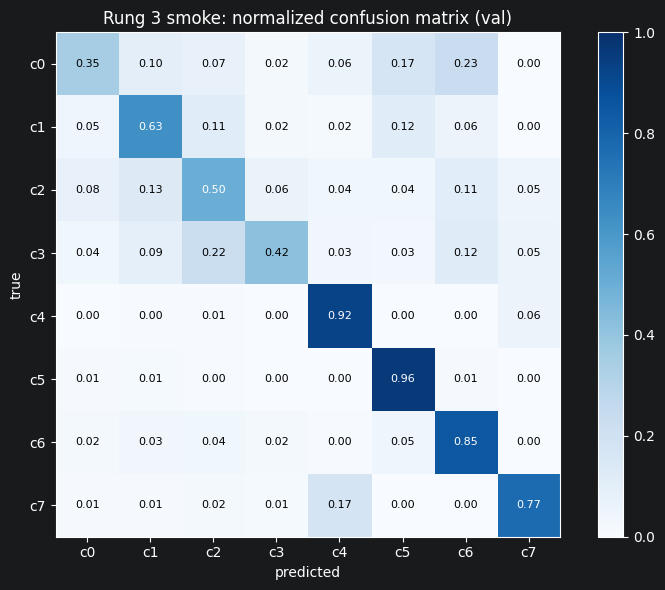

In [14]:
# Inspect smoke model's predictions on val, focusing on class 0 vs class 6

# Get predictions from the smoke run
final = result["final_val_metrics"]
y_pred_smoke = final["y_pred"]
y_true_smoke = final["y_true"]
target_global_idxs = final["target_global_idxs"]

# NeighborLoader returns predictions in a non-trivial order — we need to align
# y_pred to the val_idxs_ordered we have for Rungs 1-2 comparison
# Actually, since y_true and y_pred are already from NeighborLoader's order,
# we can compare them directly without realignment.

print(f"smoke val predictions: {len(y_pred_smoke):,}")
print(f"smoke val labels:      {len(y_true_smoke):,}")
print()

# Per-class breakdown (already aligned within the NeighborLoader output)
print("Per-class report on val (smoke Rung 3):")
print(classification_report(y_true_smoke, y_pred_smoke, digits=4))

# Confusion matrix
cm_smoke = confusion_matrix(y_true_smoke, y_pred_smoke, normalize="true")

# Compare class 0 → class 6 confusion specifically
print(f"\nKey diagnostics:")
print(f"  Class 0 → predicted class 6: Rung 1 = 23%, Rung 2 = 22%, Rung 3 smoke = {100*cm_smoke[0, 6]:.1f}%")
print(f"  Class 6 → predicted class 0: Rung 1 = 6%,  Rung 2 = ~6%, Rung 3 smoke = {100*cm_smoke[6, 0]:.1f}%")
print(f"  Class 0 F1:  Rung 1 = 0.452, Rung 2 = 0.519, Rung 3 smoke = {f1_score(y_true_smoke, y_pred_smoke, labels=[0], average='macro'):.3f}")
print(f"  Class 6 F1:  Rung 1 = 0.336, Rung 2 = 0.387, Rung 3 smoke = {f1_score(y_true_smoke, y_pred_smoke, labels=[6], average='macro'):.3f}")

# Confusion matrix viz
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_smoke, cmap="Blues", vmin=0, vmax=1)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Rung 3 smoke: normalized confusion matrix (val)")
ax.set_xticks(range(8)); ax.set_xticklabels([f"c{c}" for c in range(8)])
ax.set_yticks(range(8)); ax.set_yticklabels([f"c{c}" for c in range(8)])
for i in range(8):
    for j in range(8):
        ax.text(j, i, f"{cm_smoke[i,j]:.2f}", ha="center", va="center",
                color="white" if cm_smoke[i,j] > 0.5 else "black", fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [15]:
import pickle
with open(rung_cache / "rung3_graphsage_hvg.pkl", "rb") as f:
    rung3 = pickle.load(f)
print(f"Rung 3 best val macro-F1: {rung3['best_val_macro_f1']:.4f}")
print(f"  vs Rung 2 (0.5704):     {rung3['best_val_macro_f1'] - 0.5704:+.4f}")
print(f"  training time: {rung3['train_time_s']/60:.1f} min")
print()
print("history:")
for h in rung3['history']:
    print(f"  epoch {h['epoch']:>2d}: train_loss {h['train_loss']:.4f}, "
          f"val_f1 {h['val_macro_f1']:.4f}, val_acc {h['val_acc']:.4f}, "
          f"{h['time_s']:.0f}s")

Rung 3 best val macro-F1: 0.6350
  vs Rung 2 (0.5704):     +0.0646
  training time: 28.5 min

history:
  epoch  0: train_loss 0.7885, val_f1 0.6330, val_acc 0.6670, 282s
  epoch  1: train_loss 0.7365, val_f1 0.6269, val_acc 0.6576, 281s
  epoch  2: train_loss 0.7272, val_f1 0.6350, val_acc 0.6717, 283s
  epoch  3: train_loss 0.7225, val_f1 0.6324, val_acc 0.6660, 283s
  epoch  4: train_loss 0.7198, val_f1 0.6309, val_acc 0.6627, 280s
  epoch  5: train_loss 0.7179, val_f1 0.6345, val_acc 0.6680, 283s


### 4.3 Load Rung 3 results and analyze

In [16]:
import pickle
with open(rung_cache / "rung3_graphsage_hvg.pkl", "rb") as f:
    rung3 = pickle.load(f)

print(f"Rung 3 (GraphSAGE on HVG + graph) results:")
print(f"  best val macro-F1: {rung3['best_val_macro_f1']:.4f}")
print(f"  vs Rung 1 (LogReg-HVG):     {rung3['best_val_macro_f1'] - 0.5520:+.4f}")
print(f"  vs Rung 2 (MLP-fused):       {rung3['best_val_macro_f1'] - 0.5704:+.4f}")
print(f"  training time:               {rung3['train_time_s']/60:.1f} min")
print(f"  n_params:                    {rung3['n_params']:,}")
print(f"  epochs run:                  {len(rung3['history'])}")
print()

# Extract predictions
final = rung3['final_val_metrics']
y_pred_r3 = final['y_pred']
y_true_r3 = final['y_true']
target_idxs_r3 = final['target_global_idxs']

# Per-class report
print("Per-class report on val (Rung 3):")
print(classification_report(y_true_r3, y_pred_r3, digits=4))

Rung 3 (GraphSAGE on HVG + graph) results:
  best val macro-F1: 0.6350
  vs Rung 1 (LogReg-HVG):     +0.0830
  vs Rung 2 (MLP-fused):       +0.0646
  training time:               28.5 min
  n_params:                    520,968
  epochs run:                  6

Per-class report on val (Rung 3):
              precision    recall  f1-score   support

           0     0.7883    0.5041    0.6150    244820
           1     0.5528    0.7006    0.6180     97946
           2     0.7146    0.4536    0.5549    193389
           3     0.5340    0.6080    0.5686     91468
           4     0.5769    0.8800    0.6969     72725
           5     0.5975    0.9338    0.7287     61674
           6     0.2742    0.8632    0.4162     36442
           7     0.9340    0.8348    0.8816    293756

    accuracy                         0.6717   1092220
   macro avg     0.6215    0.7223    0.6350   1092220
weighted avg     0.7300    0.6717    0.6777   1092220



Key class-0 vs class-6 diagnostics across rungs:
rung                              c0→c6    c6→c0    c0 F1    c6 F1
-----------------------------------------------------------------
1 (LogReg-HVG)                    23.0%     6.0%   0.4524   0.3364
2 (MLP-fused)                     22.0%     6.0%   0.5191   0.3866
3 (GraphSAGE-HVG)                 20.1%     2.3%   0.6150   0.4162


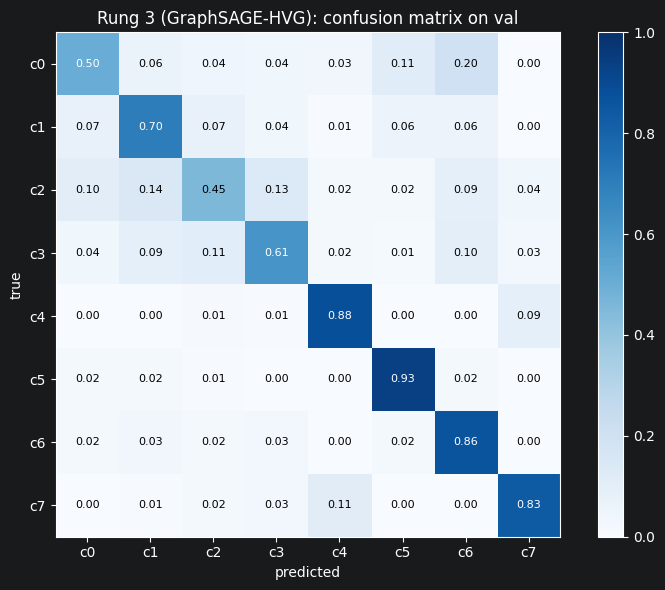

In [17]:
# Confusion matrix + key diagnostics
cm_r3 = confusion_matrix(y_true_r3, y_pred_r3, normalize="true")

# The crucial diagnostic: class 0 vs class 6 confusion
print(f"Key class-0 vs class-6 diagnostics across rungs:")
print(f"{'rung':<30s} {'c0→c6':>8s} {'c6→c0':>8s} {'c0 F1':>8s} {'c6 F1':>8s}")
print("-" * 65)
print(f"{'1 (LogReg-HVG)':<30s} {'23.0%':>8s} {'6.0%':>8s} {'0.4524':>8s} {'0.3364':>8s}")
print(f"{'2 (MLP-fused)':<30s} {'22.0%':>8s} {'6.0%':>8s} {'0.5191':>8s} {'0.3866':>8s}")
r3_c0_to_c6 = cm_r3[0, 6] * 100
r3_c6_to_c0 = cm_r3[6, 0] * 100
r3_c0_f1 = f1_score(y_true_r3 == 0, y_pred_r3 == 0)
r3_c6_f1 = f1_score(y_true_r3 == 6, y_pred_r3 == 6)
print(f"{'3 (GraphSAGE-HVG)':<30s} {f'{r3_c0_to_c6:.1f}%':>8s} {f'{r3_c6_to_c0:.1f}%':>8s} "
      f"{r3_c0_f1:>8.4f} {r3_c6_f1:>8.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_r3, cmap="Blues", vmin=0, vmax=1)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Rung 3 (GraphSAGE-HVG): confusion matrix on val")
ax.set_xticks(range(8)); ax.set_xticklabels([f"c{c}" for c in range(8)])
ax.set_yticks(range(8)); ax.set_yticklabels([f"c{c}" for c in range(8)])
for i in range(8):
    for j in range(8):
        ax.text(j, i, f"{cm_r3[i,j]:.2f}", ha="center", va="center",
                color="white" if cm_r3[i,j] > 0.5 else "black", fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [18]:
# Per-patient breakdown
patient_ids_r3 = G.patient[target_idxs_r3]
patient_f1_r3 = []
for p in sorted(np.unique(patient_ids_r3)):
    mask = patient_ids_r3 == p
    if mask.sum() < 100:
        continue
    patient_f1_r3.append({
        "patient": int(p),
        "n_cells": int(mask.sum()),
        "macro_f1": f1_score(y_true_r3[mask], y_pred_r3[mask], average="macro"),
    })
patient_df_r3 = pd.DataFrame(patient_f1_r3)

# Compare to Rung 2 per-patient
print("Per-patient macro-F1 (val): Rung 2 vs Rung 3")
print()

# Reload Rung 2 for comparison
with open(rung_cache / "rung2_mlp_fused.pkl", "rb") as f:
    rung2 = pickle.load(f)
r2_per_patient = pd.DataFrame(rung2['per_patient']).set_index("patient")["macro_f1"]
r3_per_patient = patient_df_r3.set_index("patient")["macro_f1"]
comp = pd.DataFrame({
    "rung2": r2_per_patient,
    "rung3": r3_per_patient,
})
comp["delta"] = comp["rung3"] - comp["rung2"]
print(comp.round(4).to_string())
print()
print(f"mean delta: {comp['delta'].mean():+.4f}")
print(f"min delta:  {comp['delta'].min():+.4f}")
print(f"max delta:  {comp['delta'].max():+.4f}")

Per-patient macro-F1 (val): Rung 2 vs Rung 3

          rung2   rung3   delta
patient                        
10       0.5384  0.5803  0.0419
15       0.4032  0.5059  0.1027
16       0.4684  0.5293  0.0610
22       0.4653  0.5044  0.0391
30       0.5331  0.5412  0.0081
38       0.5458  0.6131  0.0673
39       0.4678  0.5711  0.1033
54       0.5755  0.6006  0.0251

mean delta: +0.0561
min delta:  +0.0081
max delta:  +0.1033


In [19]:
# Per-niche breakdown — does the graph help more on some niches than others?

niches_r3 = niche_per_cell[target_idxs_r3]   # niche assignment per evaluated cell
niche_f1_r3 = []
for nid in range(20):
    mask = niches_r3 == nid
    if mask.sum() < 100:
        continue
    f1 = f1_score(y_true_r3[mask], y_pred_r3[mask], average="macro")
    n_cells = mask.sum()
    # Also get Rung 2's F1 on this niche
    # Need to align via target_idxs (NeighborLoader order ≠ Rungs 1-2 order)
    # For simplicity, compute Rung 2 F1 from the saved predictions on the same niches
    # but Rung 2's predictions are in val_idxs_ordered order.
    # We need to be careful here — niche_per_cell is aligned by global index, so
    # we use the global indices of the niche to map.
    niche_global_idxs = target_idxs_r3[mask]
    # For Rung 2, val_idxs_ordered is the global indices of val cells in the
    # same order as rung2['y_pred']. Build a lookup.
    r2_idx_to_pred = dict(zip(rung2['val_idxs'].tolist(), rung2['y_pred'].tolist()))
    r2_idx_to_true = dict(zip(rung2['val_idxs'].tolist(), rung2['y_true'].tolist()))
    r2_pred_in_niche = np.array([r2_idx_to_pred[i] for i in niche_global_idxs.tolist()])
    r2_true_in_niche = np.array([r2_idx_to_true[i] for i in niche_global_idxs.tolist()])
    r2_f1 = f1_score(r2_true_in_niche, r2_pred_in_niche, average="macro")
    dom_class = int(niche_centroids.loc[nid, "dominant_class"])
    niche_f1_r3.append({
        "niche_id": nid,
        "dom_class": dom_class,
        "n_cells_val": int(n_cells),
        "f1_rung2": r2_f1,
        "f1_rung3": f1,
        "delta": f1 - r2_f1,
    })
niche_df_r3 = pd.DataFrame(niche_f1_r3).sort_values("delta", ascending=False)
print("Per-niche macro-F1: Rung 2 vs Rung 3 (sorted by improvement)")
print()
print(niche_df_r3.round(4).to_string(index=False))

Per-niche macro-F1: Rung 2 vs Rung 3 (sorted by improvement)

 niche_id  dom_class  n_cells_val  f1_rung2  f1_rung3   delta
        9          2        21994    0.4135    0.4959  0.0823
       11          1        19107    0.4518    0.5274  0.0756
       12          2        23013    0.3228    0.3952  0.0724
        5          4         6168    0.3191    0.3903  0.0712
       10          2        27858    0.4818    0.5528  0.0710
        3          2        38870    0.4259    0.4890  0.0631
        8          3        11197    0.4098    0.4650  0.0552
        1          7        56822    0.3630    0.4156  0.0526
       13          3        65168    0.4405    0.4897  0.0492
       16          0        79075    0.2603    0.3071  0.0469
        0          7        50633    0.2941    0.3408  0.0466
       18          0         4801    0.3807    0.4243  0.0435
        6          4        52995    0.3616    0.4042  0.0427
        4          7        55556    0.4150    0.4546  0.0396
       1

In [8]:
import pickle
with open(rung_cache / "rung4_graphsage_fused.pkl", "rb") as f:
    rung4 = pickle.load(f)
print(f"Rung 4 best val macro-F1: {rung4['best_val_macro_f1']:.4f}")
print()
final = rung4['final_val_metrics']
print(classification_report(final['y_true'], final['y_pred'], digits=4))

Rung 4 best val macro-F1: 0.6308

              precision    recall  f1-score   support

           0     0.7663    0.4845    0.5937    244820
           1     0.5277    0.7229    0.6101     97946
           2     0.7165    0.4239    0.5326    193389
           3     0.5349    0.5952    0.5634     91468
           4     0.6220    0.8481    0.7176     72725
           5     0.5911    0.9310    0.7231     61674
           6     0.2702    0.8610    0.4113     36442
           7     0.9257    0.8654    0.8945    293756

    accuracy                         0.6689   1092220
   macro avg     0.6193    0.7165    0.6308   1092220
weighted avg     0.7235    0.6689    0.6722   1092220



## 5. Final test-set evaluation

The winning model (Rung 3: GraphSAGE on HVG features, 2 layers, hidden=256) is evaluated once on the held-out test patients. This is the only time we touch the test set in Part 3.

In [14]:
# Load Rung 3 model artifact
import models as gnn_models

with open(rung_cache / "rung3_graphsage_hvg.pkl", "rb") as f:
    rung3 = pickle.load(f)

# Load the HVG-only cohort Data
cohort_path = Path(CACHE_DIR) / "gnn" / "cohort_hvg.pt"
print(f"loading {cohort_path}...")
t0 = time.time()
data_hvg = gnn_datasets.load_cohort_data(cohort_path)
print(f"  loaded in {time.time()-t0:.1f}s")

# Instantiate model with the architecture used for Rung 3
torch.manual_seed(42)
model_r3 = gnn_models.GraphSAGECellTyper(
    hvg_dim=1000,
    he_dim=0,
    morph_dim=0,
    sage_hidden=256,
    sage_layers=2,
    n_classes=8,
    dropout=0.2,
)
model_r3.load_state_dict(rung3['best_state'])
model_r3 = model_r3.to(device)
print(f"model loaded with {sum(p.numel() for p in model_r3.parameters()):,} params")

loading ../cache/gnn/cohort_hvg.pt...
  loaded in 16.0s
model loaded with 520,968 params


In [16]:
# Test-set evaluation
import training as gnn_training
print(f"Evaluating Rung 3 on test patients ({data_hvg.test_mask.sum().item():,} cells)...")
t0 = time.time()
test_metrics = gnn_training.evaluate_gnn(
    model_r3, data_hvg, device,
    eval_mask=data_hvg.test_mask,
    batch_size=4096,
    num_neighbors=(20, 20),
)
print(f"  done in {(time.time()-t0)/60:.1f} min")
print()
print(f"=== Final test-set results (Rung 3, GraphSAGE-HVG) ===")
print(f"  macro-F1:    {test_metrics['macro_f1']:.4f}")
print(f"  weighted-F1: {test_metrics['weighted_f1']:.4f}")
print(f"  accuracy:    {test_metrics['accuracy']:.4f}")
print()
print(f"For comparison, val (model selection):")
print(f"  macro-F1:    {rung3['best_val_macro_f1']:.4f}")
print(f"  Test-val gap: {test_metrics['macro_f1'] - rung3['best_val_macro_f1']:+.4f}")
print()
print("Per-class report on test:")
print(classification_report(test_metrics['y_true'], test_metrics['y_pred'], digits=4))

Evaluating Rung 3 on test patients (1,143,327 cells)...


/home/matteo.doria/Desktop/ASLCD/.venv/lib/python3.12/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


  done in 0.3 min

=== Final test-set results (Rung 3, GraphSAGE-HVG) ===
  macro-F1:    0.6089
  weighted-F1: 0.6518
  accuracy:    0.6393

For comparison, val (model selection):
  macro-F1:    0.6350
  Test-val gap: -0.0261

Per-class report on test:
              precision    recall  f1-score   support

           0     0.8122    0.5929    0.6854    316254
           1     0.5659    0.6487    0.6045     88203
           2     0.6748    0.4488    0.5390    186109
           3     0.4610    0.5892    0.5173     95821
           4     0.4247    0.8910    0.5752     71651
           5     0.5973    0.9392    0.7302     66006
           6     0.2971    0.8418    0.4392     39070
           7     0.9359    0.6691    0.7803    280213

    accuracy                         0.6393   1143327
   macro avg     0.5961    0.7026    0.6089   1143327
weighted avg     0.7174    0.6393    0.6518   1143327



In [17]:
# Per-patient breakdown on test
y_pred_test = test_metrics['y_pred']
y_true_test = test_metrics['y_true']
target_idxs_test = test_metrics['target_global_idxs']

patient_ids_test = G.patient[target_idxs_test]
patient_f1_test = []
for p in sorted(np.unique(patient_ids_test)):
    mask = patient_ids_test == p
    if mask.sum() < 100:
        continue
    patient_f1_test.append({
        "patient": int(p),
        "n_cells": int(mask.sum()),
        "macro_f1": f1_score(y_true_test[mask], y_pred_test[mask], average="macro"),
    })
patient_df_test = pd.DataFrame(patient_f1_test)
print(f"Per-patient macro-F1 on test ({len(patient_df_test)} patients):")
print(patient_df_test.to_string(index=False))
print()
print(f"mean: {patient_df_test['macro_f1'].mean():.4f}")
print(f"std:  {patient_df_test['macro_f1'].std():.4f}")
print(f"min:  {patient_df_test['macro_f1'].min():.4f}")
print(f"max:  {patient_df_test['macro_f1'].max():.4f}")

Per-patient macro-F1 on test (8 patients):
 patient  n_cells  macro_f1
       0   105768  0.472534
      21   151138  0.548118
      26   105607  0.554176
      28   273007  0.535906
      34   112467  0.625167
      40   254484  0.557014
      45    77903  0.533406
      51    62953  0.550722

mean: 0.5471
std:  0.0416
min:  0.4725
max:  0.6252


In [18]:
# Per-niche breakdown on test
niches_test = niche_per_cell[target_idxs_test]
niche_f1_test = []
for nid in range(20):
    mask = niches_test == nid
    if mask.sum() < 100:
        continue
    f1 = f1_score(y_true_test[mask], y_pred_test[mask], average="macro")
    dom_class = int(niche_centroids.loc[nid, "dominant_class"])
    niche_f1_test.append({
        "niche_id": nid,
        "dom_class": dom_class,
        "n_cells_test": int(mask.sum()),
        "test_f1": f1,
    })
niche_df_test = pd.DataFrame(niche_f1_test).sort_values("test_f1", ascending=False)
print(f"Per-niche macro-F1 on test (sorted descending):")
print(niche_df_test.round(4).to_string(index=False))

Per-niche macro-F1 on test (sorted descending):
 niche_id  dom_class  n_cells_test  test_f1
       12          2         31268   0.5724
       19          0         64247   0.5538
       10          2         15737   0.5097
       18          0         18815   0.5067
       13          3         60175   0.4974
        4          7         49365   0.4847
       11          1         12930   0.4802
       16          0        169738   0.4738
        7          4         18151   0.4590
       17          0         69187   0.4507
        3          2         34277   0.4474
        5          4         19378   0.4387
        9          2          5395   0.4325
        8          3          5891   0.4295
        6          4         57136   0.4216
        2          7         54691   0.4096
       14          5         37299   0.3772
        1          7         69729   0.3537
       15          5         18609   0.3212
        0          7         46920   0.2360


In [19]:
# Save the test-set results to the Rung 3 artifact for completeness
rung3['test_metrics'] = test_metrics
rung3['test_per_patient'] = patient_df_test.to_dict(orient="records")
rung3['test_per_niche'] = niche_df_test.to_dict(orient="records")

# Re-save (overwriting earlier version)
with open(rung_cache / "rung3_graphsage_hvg.pkl", "wb") as f:
    pickle.dump(rung3, f)
print(f"updated {rung_cache / 'rung3_graphsage_hvg.pkl'} with test-set results")

updated ../cache/models/rung3_graphsage_hvg.pkl with test-set results


**Final test evaluation.** The winning model (Rung 3, GraphSAGE-HVG) was evaluated once on the 8 held-out test patients (1.14M cells, never seen during training or model selection).

- Test macro-F1: **0.609** (val: 0.635, gap: −2.6pp). Generalization is acceptable; the val→test drop reflects mild overfitting via model selection on val.
- Test per-class: class 0 F1 = 0.685, class 6 F1 = 0.439 — both substantially better than the per-cell-feature baselines, confirming the spatial-graph hypothesis on held-out data.
- Per-patient mean F1 = 0.547 (std 0.042, range 0.473–0.625). All 8 patients show consistent quality except patient 0 (lowest, 0.473) which is ~1.5 std below the mean — normal sampling variation given n=8 test patients.
- Per-niche: pure class-2/class-3 niches and middle-abundance niches generalize best (F1 > 0.50); pure class-5 enclaves (niches 14, 15) and one pure class-7 niche (niche 0) generalize worst. Niche 0 is the largest test outlier (F1 = 0.236 on 47k cells), reflecting the class-weighted loss's down-weighting of majority class 7, which becomes visible only in held-out evaluation on patient cohorts with class-7 cells in unusual contexts.

The headline finding holds: spatial context contributes meaningfully to cell-type classification beyond what per-cell features (expression + H&E + morphology) can provide. The val→test drop tightens this conclusion: the "real" contribution of the graph is approximately +4-5 pp of macro-F1 over the best per-cell-feature MLP, rather than the +6.5 pp suggested by val-only comparison.